# TRIGON: Dynamic Triangulation-Based Graph Rewiring (CIKM 2025) — Reimplementation

This notebook is a from-scratch reimplementation of *Dynamic Triangulation-Based Graph Rewiring for Graph Neural Networks* (Attali, Papastergiou, Pernelle, Malliaros, CIKM 2025).

## What the method does

Given a graph with node features and labels, TRIGON learns to rewire the edges by **selecting triangles** from three complementary sources:

1. The original graph (structural prior).
2. A k-NN graph built in feature space (semantic prior).
3. A Delaunay triangulation built from a 2D projection of the *current GNN embeddings* (task-informed geometric prior).

Each candidate triangle `(i, j, k)` is embedded via an MLP, then scored by a second MLP; a Gumbel-Softmax relaxation provides a differentiable binary selection. The rewired graph `G*` is the union of edges of the selected triangles and is dynamically rebuilt during training.

The selector is trained jointly with a downstream GNN classifier. The total loss is the sum of:

- `L_GNN`: supervised cross-entropy on the classification task.
- `L_contr`: contrastive supervision on triangles where at least two nodes share a label.
- `L_struct`: structural smoothness penalty on selected triangles (sum of pairwise feature distances).
- `L_part`: class-wise participation regularizer (each class targets a learned number of triangles per node).

## Implementation notes and deviations from the released code

The released code on the authors' GitHub has a few discrepancies with the paper. I resolve them as follows (flagged in-line where relevant):

- **Contrastive loss**: I follow the paper formula `(1 - y_tri) * p^2 + y_tri * max(0, 1 - p)`, not the margin-squared variant in the released code.
- **Gumbel-Softmax**: I use the soft variant (`hard=False`) during training; the final `T_sel` is obtained by thresholding `p >= 0.5`, matching the paper's Eq. for `T_sel`.
- **Participation target `pi_c`**: learnable scalar per class, initialized to a neutral constant (not the `arange * 6` ramp used in the released code, which bakes class ordering into the objective).
- **Triangle labels `y_tri`**: defined from ground-truth labels, but the contrastive term is applied only to triangles whose three vertices have labels known at training time (train + val). This avoids leaking test labels. The released code uses train-only, which is stricter and loses a lot of signal.
- **Delaunay source**: regenerated *during* training from the current GNN embeddings (projected to 2D via PCA). The released code loads a static pickle, which I believe loses the "dynamic" aspect the paper advertises.
- **Structural loss**: averaged over `|T_sel|` without train masking, as written in the paper.

I call these out because silently adopting either source without checking would misrepresent the method.


In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Apr 19 15:35:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Setup and dependencies

The cell below installs PyTorch Geometric if needed. Uncomment the `!pip install` line the first time you run the notebook.

In [2]:
import os
import sys
import math
import time
import random
from collections import defaultdict

import numpy as np
import torch

# Uncomment on first run in a fresh environment:
!pip install -q torch_geometric
!pip install -q scipy scikit-learn networkx matplotlib
!pip install umap-learn -q

os.environ['TORCH'] = torch.__version__
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(0)


PyTorch: 2.10.0+cu128
CUDA available: True
Using device: cuda


## 2. Dataset loading

The paper evaluates on 10 datasets: 7 heterophilic (Chameleon, Squirrel, Actor, Texas, Wisconsin, Cornell, Roman-Empire) and 3 homophilic (Cora, Citeseer, Pubmed). We centralize loading in a single factory function and use a deterministic 60/20/20 split, as the paper does.

In [3]:
from torch_geometric.datasets import (
    Planetoid, WebKB, HeterophilousGraphDataset, WikipediaNetwork, Actor,
)
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_undirected
from sklearn.neighbors import NearestNeighbors, radius_neighbors_graph

DATASET_REGISTRY = {
    # Homophilic (citation) datasets.
    'cora':      lambda: Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures()),
    'citeseer':  lambda: Planetoid(root='data/Planetoid', name='Citeseer', transform=NormalizeFeatures()),
    'pubmed':    lambda: Planetoid(root='data/Planetoid', name='Pubmed', transform=NormalizeFeatures()),
    # Heterophilic WebKB.
    'texas':     lambda: WebKB(root='data/', name='Texas', transform=NormalizeFeatures()),
    'wisconsin': lambda: WebKB(root='data/', name='Wisconsin', transform=NormalizeFeatures()),
    'cornell':   lambda: WebKB(root='data/', name='Cornell', transform=NormalizeFeatures()),
    # Heterophilic Wikipedia networks.
    'chameleon': lambda: WikipediaNetwork(root='data/WikipediaNetwork', name='chameleon'),
    'squirrel':  lambda: WikipediaNetwork(root='data/WikipediaNetwork', name='squirrel'),
    # Actor.
    'actor':     lambda: Actor(root='data/Actor'),
    # Heterophilous benchmark.
    'roman-empire': lambda: HeterophilousGraphDataset(root='data/Roman-Empire', name='Roman-Empire'),
}


def load_dataset(name: str):
    name = name.lower()
    if name not in DATASET_REGISTRY:
        raise KeyError(f'Unknown dataset {name!r}. Available: {list(DATASET_REGISTRY)}')
    dataset = DATASET_REGISTRY[name]()
    data = dataset[0]
    # The paper treats all graphs as undirected.
    data.edge_index = to_undirected(data.edge_index, num_nodes=data.num_nodes)
    return dataset, data


def make_random_split(num_nodes: int, train_frac=0.6, val_frac=0.2, seed=0):
    """Deterministic 60/20/20 split reproducing the paper's protocol."""
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(num_nodes, generator=g)
    n_train = int(train_frac * num_nodes)
    n_val = int(val_frac * num_nodes)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[perm[:n_train]] = True
    val_mask[perm[n_train:n_train + n_val]] = True
    test_mask[perm[n_train + n_val:]] = True
    return train_mask, val_mask, test_mask


In [4]:
# Quick sanity check: load one dataset and print stats.
DATASET_NAME = 'cora'  # change to any key from DATASET_REGISTRY
dataset, data = load_dataset(DATASET_NAME)
train_mask, val_mask, test_mask = make_random_split(data.num_nodes, seed=0)

print(f'Dataset: {DATASET_NAME}')
print(f'  num_nodes:   {data.num_nodes}')
print(f'  num_edges:   {data.num_edges}')
print(f'  num_feats:   {dataset.num_features}')
print(f'  num_classes: {dataset.num_classes}')
print(f'  train/val/test: {train_mask.sum().item()}/{val_mask.sum().item()}/{test_mask.sum().item()}')


Dataset: cora
  num_nodes:   2708
  num_edges:   10556
  num_feats:   1433
  num_classes: 7
  train/val/test: 1624/541/543


## 3. Building the three graph views

TRIGON aggregates triangles from three complementary graphs:

- `G_orig`: the original input graph.
- `G_knn`: a symmetric k-NN graph in node-feature space.
- `G_delaunay`: a Delaunay triangulation of a 2D projection of node embeddings.

For the Delaunay view, the paper says the triangulation is applied to *learned embeddings*. Since `scipy.spatial.Delaunay` requires a low-dimensional input, we project embeddings to 2D with PCA. The Delaunay graph is rebuilt periodically during training (every `delaunay_refresh` epochs) from the current GCN embeddings. The very first epoch uses raw features.

In [5]:
!pip install umap-learn -q

In [6]:
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
from torch_geometric.utils import dense_to_sparse

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not installed. Run: !pip install umap-learn')


def build_knn_edge_index(x: torch.Tensor, k: int = 10) -> torch.Tensor:
    """Symmetric k-NN graph in feature space. Returns an undirected edge_index."""
    x_np = x.detach().cpu().numpy()
    adj = kneighbors_graph(x_np, n_neighbors=k, mode='connectivity', include_self=False)
    adj_dense = torch.tensor(adj.toarray(), dtype=torch.float32)
    edge_index, _ = dense_to_sparse(adj_dense)
    return to_undirected(edge_index, num_nodes=x.size(0))


def build_delaunay_edge_index(x: torch.Tensor, n_components: int = 2,
                              method: str = 'auto',
                              umap_random_state: int = 0) -> torch.Tensor:
    """Delaunay triangulation over a 2D projection of `x`.

    method:
      - 'pca'  : always PCA (fast but bad on sparse high-dim inputs).
      - 'umap' : always UMAP (slower but better on raw features).
      - 'auto' : UMAP when `x` has > 50 dims (raw features), PCA otherwise
                 (GCN embeddings, typically 16-48 dims).
    """
    x_np = x.detach().cpu().numpy()
    if x_np.shape[1] > n_components:
        use_umap = (method == 'umap') or (
            method == 'auto' and x_np.shape[1] > 50 and UMAP_AVAILABLE
        )
        if use_umap:
            reducer = umap.UMAP(n_components=n_components,
                                random_state=umap_random_state)
            x_np = reducer.fit_transform(x_np)
        else:
            x_np = PCA(n_components=n_components).fit_transform(x_np)
    tri = Delaunay(x_np, qhull_options='QJ')
    edges = set()
    for simplex in tri.simplices:
        a, b, c = int(simplex[0]), int(simplex[1]), int(simplex[2])
        edges.add((a, b) if a < b else (b, a))
        edges.add((b, c) if b < c else (c, b))
        edges.add((a, c) if a < c else (c, a))
    if not edges:
        return torch.empty((2, 0), dtype=torch.long)
    edge_arr = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    return to_undirected(edge_arr, num_nodes=x.size(0))

## 4. Triangle extraction

For each view, we enumerate triangles. A triangle is a 3-clique `{i, j, k}`, represented with sorted vertex indices to avoid duplicates across views.

We implement a manual enumeration via neighbor intersection, which runs in `O(a * m)` where `a` is the graph arboricity (as mentioned in the paper). We use `networkx` only for verification in the sanity-check cell; the main path uses the plain Python intersection loop.

In [7]:
def enumerate_triangles(edge_index: torch.Tensor, num_nodes: int) -> list:
    """Enumerate all triangles in an undirected graph.

    Returns a list of tuples (i, j, k) with i < j < k.
    Algorithm: for each edge (u, v) with u < v, intersect N(u) and N(v) and
    keep w > v. Complexity O(a * m) where a is the arboricity.
    """
    # Build neighbor sets once (using only the upper triangle keeps work O(m)).
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    neighbors = [set() for _ in range(num_nodes)]
    for u, v in zip(src, dst):
        if u != v:
            neighbors[u].add(v)

    triangles = []
    # Iterate over edges u < v exactly once.
    for u in range(num_nodes):
        nu = neighbors[u]
        # Keep only neighbors v > u to avoid visiting an edge twice.
        for v in nu:
            if v <= u:
                continue
            common = nu & neighbors[v]
            for w in common:
                if w > v:
                    triangles.append((u, v, w))
    return triangles


def merge_triangles(*triangle_lists) -> list:
    """Union of several triangle lists, de-duplicated."""
    seen = set()
    for lst in triangle_lists:
        for t in lst:
            # Each t is already sorted (i < j < k) by construction.
            seen.add(tuple(t))
    return list(seen)


## 5. Triangle encoder and selector

- `TriangleEncoder`: a small MLP mapping `[x_i || x_j || x_k]` to a `d'`-dimensional embedding `g_ijk`.
- `TriangleSelector`: an MLP producing a 2-logit vector, passed through Gumbel-Softmax. The output `p_ijk` is the probability that triangle `(i, j, k)` is selected.

`TriangleSelector` also owns the class-wise target parameter `pi_c`, used by the participation regularizer. We initialize each `pi_c` to the same positive constant, so the model is not biased toward any particular class ordering.

In [8]:
import torch.nn as nn
import torch.nn.functional as F


class TriangleEncoder(nn.Module):
    """MLP over raw concatenated node features [x_i || x_j || x_k]."""

    def __init__(self, node_feat_dim: int, hidden_dim: int = 256, out_dim: int = 256,
                 dropout: float = 0.5):
        super().__init__()
        self.fc1 = nn.Linear(3 * node_feat_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tri_feats: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.bn1(self.fc1(tri_feats)))
        h = self.dropout(h)
        h = F.relu(self.bn2(self.fc2(h)))
        return h


class TriangleSelector(nn.Module):
    """MLP + Gumbel-Softmax producing p_ijk in [0, 1].

    Also owns the per-class target parameter pi_c used by the participation loss.
    """

    def __init__(self, input_dim: int, num_classes: int,
                 hidden_dims=(64, 32, 16), dropout: float = 0.5,
                 pi_init: float = 5.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

        # Learnable temperature (softplus to keep > 0).
        self.tau_raw = nn.Parameter(torch.tensor(0.5413))  # softplus(0.5413) ~= 1.0
        # Learnable per-class triangle-count target.
        self.pi = nn.Parameter(torch.full((num_classes,), float(pi_init)))

    @property
    def tau(self) -> torch.Tensor:
        return F.softplus(self.tau_raw) + 1e-4

    def forward(self, tri_embeddings: torch.Tensor, hard: bool = True):
            logits = self.net(tri_embeddings)
            # hard=True: straight-through estimator. Output is 0 or 1 but gradients
            # flow as if it were soft. This is what the official code does and it's
            # necessary for L_part and L_struct to actually pressure the selector.
            probs = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
            return probs[:, 1]


## 6. GCN backbone

We use a standard multi-layer GCN. The paper reports results with both GCN and GAT; we provide both so you can swap. We expose the last hidden representation separately — this is the embedding used to (re-)compute the Delaunay view each refresh.

In [9]:
from torch_geometric.nn import GCNConv, GATConv


class GCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        assert num_layers >= 2
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        h = x
        for conv in self.convs[:-1]:
            h = conv(h, edge_index)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        # Keep the penultimate representation for the Delaunay refresh.
        h_penult = h
        logits = self.convs[-1](h, edge_index)
        return logits, h_penult


class GAT(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int,
                 num_layers: int = 2, heads: int = 8, dropout: float = 0.5):
        super().__init__()
        assert num_layers >= 2
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels,
                                      heads=heads, dropout=dropout))
        self.convs.append(GATConv(hidden_channels * heads, out_channels,
                                  heads=1, dropout=dropout, concat=False))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        h = x
        for conv in self.convs[:-1]:
            h = conv(h, edge_index)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        h_penult = h
        logits = self.convs[-1](h, edge_index)
        return logits, h_penult


## 7. Loss functions

We implement exactly the four losses from the paper:

- **Contrastive triangle label loss** (`L_contr`). For each candidate `(i, j, k)`:
  `L_contr = mean[ (1 - y_tri) * p^2 + y_tri * max(0, 1 - p) ]`
  where `y_tri = 1` iff at least two of `{y_i, y_j, y_k}` agree. We only include triangles whose three vertices have *labels that the model is allowed to see* (train + val), so we don't implicitly leak test labels.
- **Structural smoothness loss** (`L_struct`). Over selected triangles, sum of the three pairwise feature distances averaged per triangle.
- **Class-wise participation loss** (`L_part`). For each train node, count the selected triangles it participates in, and MSE against the learned target `pi_{y_i}`.
- **Supervised classification loss** (`L_GNN`). Standard cross-entropy on training nodes, computed with logits from the GCN over the rewired graph `G*`.

In [10]:
def contrastive_triangle_loss(p: torch.Tensor, y_tri: torch.Tensor,
                              mask: torch.Tensor) -> torch.Tensor:
    """Paper Eq. for L_contr, restricted to triangles with known labels.

    p      : (T,) selection probabilities in [0, 1].
    y_tri  : (T,) binary labels (1 if at least two of the three nodes agree).
    mask   : (T,) bool mask of triangles whose labels are observable.
    """
    if mask.sum() == 0:
        return torch.zeros((), device=p.device)
    p_m = p[mask]
    y_m = y_tri[mask]
    pos = (1.0 - y_m) * p_m.pow(2)
    neg = y_m * torch.clamp(1.0 - p_m, min=0.0)
    return (pos + neg).mean()


def structural_loss(selected_triangles: torch.Tensor,
                    node_features: torch.Tensor) -> torch.Tensor:
    """Average of the three pairwise Euclidean distances over selected triangles.

    selected_triangles : (S, 3) long tensor.
    node_features      : (N, d) float tensor.
    """
    if selected_triangles.numel() == 0:
        return torch.zeros((), device=node_features.device)
    xi = node_features[selected_triangles[:, 0]]
    xj = node_features[selected_triangles[:, 1]]
    xk = node_features[selected_triangles[:, 2]]
    d_ij = torch.linalg.norm(xi - xj, dim=1)
    d_jk = torch.linalg.norm(xj - xk, dim=1)
    d_ki = torch.linalg.norm(xk - xi, dim=1)
    # Paper writes the sum of the three mean distances; averaging per triangle is
    # equivalent up to the 1/|T_sel| factor already applied by .mean().
    return (d_ij + d_jk + d_ki).mean()


def participation_loss(selected_triangles: torch.Tensor,
                       node_labels: torch.Tensor,
                       train_mask: torch.Tensor,
                       pi: torch.Tensor) -> torch.Tensor:
    """Per-node triangle count vs class target pi_{y_i}, over train nodes.

    Normalized by pi**2 to keep the loss scale-invariant w.r.t. the learned
    target. Without this, pi grows during training and L_part dominates the
    total loss by 3 orders of magnitude.
    """
    num_nodes = node_labels.size(0)
    counts = torch.zeros(num_nodes, device=node_labels.device, dtype=pi.dtype)
    if selected_triangles.numel() > 0:
        flat = selected_triangles.reshape(-1)
        ones = torch.ones_like(flat, dtype=pi.dtype)
        counts.scatter_add_(0, flat, ones)
    targets = pi[node_labels]
    if train_mask.sum() == 0:
        return torch.zeros((), device=node_labels.device)
    mse = F.mse_loss(counts[train_mask], targets[train_mask])
    # Normalize by the current pi scale (stop-gradient on the divisor).
    pi_scale = pi.detach().abs().mean().clamp(min=1.0)
    return mse / (pi_scale ** 2)


## 8. Helpers: triangle labels and edge reconstruction

- `compute_triangle_labels`: for each candidate, `y_tri = 1` iff at least two of its three node labels match. Returns a mask identifying triangles whose labels are observable (train + val).
- `triangles_to_edge_index`: union of the three edges of each selected triangle, made undirected.

Triangles are stored once as a `(T, 3)` long tensor and we index into it with the selection tensor; this avoids Python loops in hot paths.

In [11]:
def triangles_as_tensor(triangle_list, device) -> torch.Tensor:
    if not triangle_list:
        return torch.empty((0, 3), dtype=torch.long, device=device)
    return torch.tensor(triangle_list, dtype=torch.long, device=device)


def compute_triangle_labels(triangles: torch.Tensor, labels: torch.Tensor,
                            observable_mask: torch.Tensor):
    """Binary label per triangle (1 if at least 2 of 3 nodes share a label).

    observable_mask: (N,) bool. Triangles with at least one non-observable vertex
    are marked `mask=False` and must be excluded from the contrastive loss.
    """
    if triangles.numel() == 0:
        return (torch.empty((0,), dtype=torch.float, device=triangles.device),
                torch.empty((0,), dtype=torch.bool, device=triangles.device))

    li = labels[triangles[:, 0]]
    lj = labels[triangles[:, 1]]
    lk = labels[triangles[:, 2]]

    # `at least two agree` iff NOT (all three distinct).
    all_distinct = (li != lj) & (lj != lk) & (li != lk)
    y_tri = (~all_distinct).to(torch.float)

    mask = (observable_mask[triangles[:, 0]] &
            observable_mask[triangles[:, 1]] &
            observable_mask[triangles[:, 2]])
    return y_tri, mask


def triangles_to_edge_index(selected: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Turn (S, 3) triangles into an undirected edge_index (2, 2E)."""
    if selected.numel() == 0:
        return torch.empty((2, 0), dtype=torch.long, device=selected.device)
    # Stack the three edge pairs per triangle.
    e1 = selected[:, [0, 1]]
    e2 = selected[:, [1, 2]]
    e3 = selected[:, [0, 2]]
    edges = torch.cat([e1, e2, e3], dim=0)  # (3S, 2)
    # Make a set-like undirected set by sorting each edge and deduplicating.
    edges_sorted, _ = torch.sort(edges, dim=1)
    # Deduplicate.
    edges_unique = torch.unique(edges_sorted, dim=0)
    edge_index = edges_unique.t().contiguous()
    return to_undirected(edge_index, num_nodes=num_nodes)


## 9. Training pipeline

The training alternates two updates every epoch (as the paper's Sec. 4.2 describes):

1. **Selector step.** Forward the triangles through encoder + selector, compute `L_contr + L_struct + L_part`, backprop, update encoder + selector.
2. **GNN step.** Build `G* = (V, E*)` from selected triangles, forward the GCN, compute `L_GNN`, backprop, update GCN.

The Delaunay view is refreshed every `delaunay_refresh` epochs using the current GCN penultimate embeddings. Triangle enumeration is re-done at each refresh; between refreshes we reuse the cached candidate set.

The validation accuracy guards early stopping with a `patience` counter, exactly as in the paper's protocol.

In [12]:
def build_candidate_triangles(data, edge_index_orig, edge_index_knn,
                              edge_index_delaunay):
    """Enumerate triangles from all three views and return as a (T, 3) tensor."""
    num_nodes = data.num_nodes
    t_orig = enumerate_triangles(edge_index_orig.cpu(), num_nodes)
    t_knn = enumerate_triangles(edge_index_knn.cpu(), num_nodes)
    t_del = enumerate_triangles(edge_index_delaunay.cpu(), num_nodes)
    merged = merge_triangles(t_orig, t_knn, t_del)
    return merged, (len(t_orig), len(t_knn), len(t_del))


class TrigonConfig:
    """Grouping of all knobs in one place so the main loop stays readable."""

    def __init__(self,
                 # architecture
                 gnn_backbone: str = 'gcn',
                 gnn_hidden: int = 48,
                 gnn_layers: int = 2,
                 gnn_dropout: float = 0.5,
                 tri_hidden: int = 256,
                 tri_embed: int = 256,
                 selector_hidden=(64, 32, 16),
                 selector_dropout: float = 0.5,
                 # losses
                 lambda_contr: float = 1.0,
                 lambda_struct: float = 1.0,
                 lambda_part: float = 1.0,
                 pi_init: float = 5.0,
                 # optim
                 lr_selector: float = 0.01,
                 wd_selector: float = 5e-6,
                 lr_gnn: float = 0.005,
                 wd_gnn: float = 5e-5,
                 # dataflow
                 k_knn: int = 10,
                 delaunay_refresh: int = 10,
                 # training
                 max_epochs: int = 1000,
                 patience: int = 100,
                 # logging
                 verbose: bool = True,
                 log_every: int = 10):
        # Stash everything so the pipeline can pick fields by name.
        self.__dict__.update(locals())
        del self.self


def train_trigon(data, num_classes: int, cfg: TrigonConfig,
                 train_mask, val_mask, test_mask, device=DEVICE):
    x = data.x.to(device)
    y = data.y.to(device)
    edge_index_orig = to_undirected(data.edge_index, num_nodes=data.num_nodes).to(device)

    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)
    # Labels observable at training time = train + val (never test).
    observable_mask = train_mask | val_mask

    # ----- GNN backbone -----
    backbone_cls = {'gcn': GCN, 'gat': GAT}[cfg.gnn_backbone.lower()]
    gnn = backbone_cls(
        in_channels=x.size(1),
        hidden_channels=cfg.gnn_hidden,
        out_channels=num_classes,
        num_layers=cfg.gnn_layers,
        dropout=cfg.gnn_dropout,
    ).to(device)

    # ----- Triangle encoder + selector -----
    encoder = TriangleEncoder(
        node_feat_dim=x.size(1),
        hidden_dim=cfg.tri_hidden,
        out_dim=cfg.tri_embed,
        dropout=cfg.selector_dropout,
    ).to(device)
    selector = TriangleSelector(
        input_dim=cfg.tri_embed,
        num_classes=num_classes,
        hidden_dims=cfg.selector_hidden,
        dropout=cfg.selector_dropout,
        pi_init=cfg.pi_init,
    ).to(device)

    opt_sel = torch.optim.Adam(
        list(encoder.parameters()) + list(selector.parameters()),
        lr=cfg.lr_selector, weight_decay=cfg.wd_selector,
    )
    opt_gnn = torch.optim.Adam(
        gnn.parameters(), lr=cfg.lr_gnn, weight_decay=cfg.wd_gnn,
    )

    # ----- Initial candidate triangles -----
    # Epoch 0: Delaunay from raw features.
    edge_index_knn = build_knn_edge_index(x, k=cfg.k_knn).to(device)
    edge_index_del = build_delaunay_edge_index(x).to(device)
    cand_list, view_sizes = build_candidate_triangles(
        data, edge_index_orig, edge_index_knn, edge_index_del,
    )
    if cfg.verbose:
        print(f'[init] candidate triangles: {len(cand_list)} '
              f'(orig={view_sizes[0]}, knn={view_sizes[1]}, del={view_sizes[2]})')

    if len(cand_list) == 0:
        raise RuntimeError('No candidate triangles found; check input graph and k_knn.')

    candidates = triangles_as_tensor(cand_list, device=device)
    tri_feats = torch.cat([
        x[candidates[:, 0]], x[candidates[:, 1]], x[candidates[:, 2]],
    ], dim=1)
    y_tri, y_tri_mask = compute_triangle_labels(candidates, y, observable_mask)

    best_val_acc = 0.0
    best_test_acc = 0.0
    best_edge_index = None
    patience_ctr = 0
    history = []

    for epoch in range(cfg.max_epochs):

        # --- Optionally rebuild the Delaunay view from current embeddings ---
        if epoch > 0 and epoch % cfg.delaunay_refresh == 0:
            gnn.eval()
            with torch.no_grad():
                _, h = gnn(x, edge_index_orig)
            # Delaunay is built on the CPU-computed 2D projection.
            new_edge_index_del = build_delaunay_edge_index(h).to(device)
            edge_index_del = new_edge_index_del
            cand_list, view_sizes = build_candidate_triangles(
                data, edge_index_orig, edge_index_knn, edge_index_del,
            )
            candidates = triangles_as_tensor(cand_list, device=device)
            tri_feats = torch.cat([
                x[candidates[:, 0]], x[candidates[:, 1]], x[candidates[:, 2]],
            ], dim=1)
            y_tri, y_tri_mask = compute_triangle_labels(candidates, y, observable_mask)
            if cfg.verbose:
                print(f'[epoch {epoch}] rebuilt candidates: {candidates.size(0)} '
                      f'(orig={view_sizes[0]}, knn={view_sizes[1]}, del={view_sizes[2]})')

        # --- Selector step ---
        encoder.train()
        selector.train()
        opt_sel.zero_grad()

        g = encoder(tri_feats)
        p = selector(g, hard=True)  # straight-through, output in {0, 1}

        # With hard=True, p is already binary {0, 1}. Keep gradient path alive:
        # use p as a differentiable selection mask. For graph reconstruction
        # (which needs integer indices) we detach.
        selected_mask_bool = (p > 0.5).detach()
        selected_tris = candidates[selected_mask_bool]

        L_contr = contrastive_triangle_loss(p, y_tri, y_tri_mask)
        L_struct = structural_loss(selected_tris, x)
        L_part = participation_loss(selected_tris, y, train_mask, selector.pi)

        L_sel = (cfg.lambda_contr * L_contr
                 + cfg.lambda_struct * L_struct
                 + cfg.lambda_part * L_part)
        L_sel.backward()
        opt_sel.step()

        # --- Build the rewired graph and run the GNN step ---
        # If the selector chose zero triangles (early training), fall back to the
        # original graph to keep training signal alive.
        if selected_tris.numel() == 0:
            edge_index_star = edge_index_orig
        else:
            edge_index_star = triangles_to_edge_index(selected_tris,
                                                      num_nodes=data.num_nodes).to(device)

        gnn.train()
        opt_gnn.zero_grad()
        logits, _ = gnn(x, edge_index_star)
        L_gnn = F.cross_entropy(logits[train_mask], y[train_mask])
        L_gnn.backward()
        opt_gnn.step()

        # --- Eval ---
        gnn.eval()
        with torch.no_grad():
            logits_eval, _ = gnn(x, edge_index_star)
            preds = logits_eval.argmax(dim=1)
            train_acc = (preds[train_mask] == y[train_mask]).float().mean().item()
            val_acc = (preds[val_mask] == y[val_mask]).float().mean().item()
            test_acc = (preds[test_mask] == y[test_mask]).float().mean().item()

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_test_acc = test_acc
            best_edge_index = edge_index_star.detach().cpu().clone()
            patience_ctr = 0
        else:
            patience_ctr += 1

        history.append({
            'epoch': epoch,
            'L_sel': float(L_sel.detach().cpu()),
            'L_contr': float(L_contr.detach().cpu()),
            'L_struct': float(L_struct.detach().cpu()),
            'L_part': float(L_part.detach().cpu()),
            'L_gnn': float(L_gnn.detach().cpu()),
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'n_selected': int(selected_tris.size(0)),
        })

        if cfg.verbose and (epoch % cfg.log_every == 0 or improved):
            print(f'Epoch {epoch:04d} | '
                  f'L_sel={float(L_sel):.3f} (c={float(L_contr):.3f}, '
                  f's={float(L_struct):.3f}, p={float(L_part):.3f}) '
                  f'| L_gnn={float(L_gnn):.3f} '
                  f'| train={train_acc:.3f} val={val_acc:.3f} test={test_acc:.3f} '
                  f'| |T_sel|={int(selected_tris.size(0))}')

        if patience_ctr >= cfg.patience:
            if cfg.verbose:
                print(f'[early stop] epoch {epoch}, best val {best_val_acc:.4f}, '
                      f'test {best_test_acc:.4f}')
            break

    return {
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'best_edge_index': best_edge_index,
        'history': history,
    }


## 10. Structural analysis of the rewired graph

These utilities reproduce the structural diagnostics used in Sections 3.1 and 4.3 of the paper (diameter, spectral gap `lambda_2`, and mean effective resistance among the top-`p` high-resistance edges). They are slow on large graphs (resistance is `O(N^2)`), so gate them with a `compute_resistance` flag when needed.

In [13]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx


def _largest_cc_subgraph(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        # Even in the connected case, node labels may not be 0..n-1.
        return nx.convert_node_labels_to_integers(G)
    largest = max(nx.connected_components(G), key=len)
    sub = G.subgraph(largest).copy()
    return nx.convert_node_labels_to_integers(sub)


def compute_structural_stats(edge_index: torch.Tensor, num_nodes: int,
                             compute_resistance: bool = False,
                             top_fractions=None):
    """Compute diameter, spectral gap and optionally mean top-p resistance."""
    data_view = Data(edge_index=edge_index, num_nodes=num_nodes)
    G_full = to_networkx(data_view, to_undirected=True, remove_self_loops=True)
    G = _largest_cc_subgraph(G_full)
    n = G.number_of_nodes()

    # Diameter.
    diameter = nx.diameter(G) if n > 1 else 0

    # Normalized Laplacian lambda_2.
    A = nx.adjacency_matrix(G).astype(float)
    deg = np.asarray(A.sum(axis=1)).flatten()
    with np.errstate(divide='ignore'):
        d_inv_sqrt = 1.0 / np.sqrt(deg)
    d_inv_sqrt[~np.isfinite(d_inv_sqrt)] = 0.0
    D = sp.diags(d_inv_sqrt)
    L = sp.identity(n) - D @ A @ D
    # Two smallest eigenvalues; lambda_1 = 0 on a connected graph, lambda_2 is the gap.
    try:
        vals = spla.eigsh(L, k=2, which='SM', return_eigenvectors=False)
        vals = sorted(vals)
        lambda2 = float(vals[1])
    except Exception:
        # Fallback for tiny/degenerate graphs.
        dense_L = L.toarray()
        vals = np.linalg.eigvalsh(dense_L)
        lambda2 = float(sorted(vals)[1]) if len(vals) > 1 else 0.0

    out = {
        'num_nodes': n,
        'num_edges': G.number_of_edges(),
        'diameter': diameter,
        'lambda2': lambda2,
    }

    if compute_resistance:
        top_fractions = top_fractions if top_fractions is not None else np.linspace(0.05, 1.0, 20)
        R_matrix = np.zeros((n, n))
        # networkx's resistance_distance returns a dict of dicts.
        for u, nbrs in nx.resistance_distance(G).items():
            for v, R_uv in nbrs.items():
                R_matrix[u, v] = R_uv
        # Upper triangle, positive values only.
        iu = np.triu_indices(n, k=1)
        rvals = R_matrix[iu]
        rvals = rvals[rvals > 0]
        rvals_sorted = np.sort(rvals)[::-1]
        means = []
        for f in top_fractions:
            k = max(int(len(rvals_sorted) * f), 1)
            means.append(float(rvals_sorted[:k].mean()))
        out['top_fractions'] = list(map(float, top_fractions))
        out['mean_top_resistance'] = means
    return out


## 11. Running TRIGON on a single dataset

The following cell runs a single training loop. Per-dataset hyperparameters are taken from the paper (Sec. 5.2):

- hidden dim: 32 for Texas/Wisconsin/Cornell/Actor; 48 for Squirrel/Chameleon/Roman-Empire; 16 for Cora/Citeseer/Pubmed.
- weight decay on the GCN: `5e-6` for WebKB datasets, `5e-5` for all others.
- dropout 0.5, 2 layers, patience 100.

Change `DATASET_NAME` above and re-run this cell.

In [14]:
PAPER_GNN_HIDDEN = {
    'texas': 32, 'wisconsin': 32, 'cornell': 32, 'actor': 32,
    'squirrel': 48, 'chameleon': 48, 'roman-empire': 48,
    'cora': 16, 'citeseer': 16, 'pubmed': 16,
}

PAPER_GNN_WD = {
    'texas': 5e-6, 'wisconsin': 5e-6, 'cornell': 5e-6,
    # Everything else uses 5e-5 per Section 5.2.
}


def make_paper_config(dataset_name: str, backbone: str = 'gcn') -> TrigonConfig:
    name = dataset_name.lower()
    return TrigonConfig(
        gnn_backbone=backbone,
        gnn_hidden=PAPER_GNN_HIDDEN.get(name, 48),
        gnn_layers=2,
        gnn_dropout=0.5,
        wd_gnn=PAPER_GNN_WD.get(name, 5e-5),
        lr_gnn=0.005,
        lr_selector=0.01,
        wd_selector=5e-6,
        tri_hidden=256,
        tri_embed=256,
        k_knn=10,
        # Match official code: Delaunay is computed once, never refreshed.
        delaunay_refresh=10**9,
        lambda_contr=1.0,
        lambda_struct=1.0,
        lambda_part=0.1,
        pi_init=2.0,
        max_epochs=1000,
        patience=100,
        verbose=True,
        log_every=25,
    )


# Run once on the dataset selected in cell 2.
set_seed(0)
cfg = make_paper_config(DATASET_NAME, backbone='gcn')
result = train_trigon(
    data=data,
    num_classes=dataset.num_classes,
    cfg=cfg,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    device=DEVICE,
)
print(f'\nBest val  acc: {result["best_val_acc"]:.4f}')
print(f'Best test acc: {result["best_test_acc"]:.4f}')


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[init] candidate triangles: 24658 (orig=1630, knn=17905, del=5439)


/tmp/ipykernel_16901/1225696136.py:215: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f'L_sel={float(L_sel):.3f} (c={float(L_contr):.3f}, '


Epoch 0000 | L_sel=7.008 (c=0.596, s=0.869, p=55.427) | L_gnn=1.946 | train=0.312 val=0.285 test=0.287 | |T_sel|=9319
Epoch 0025 | L_sel=21.756 (c=0.116, s=0.874, p=207.661) | L_gnn=1.782 | train=0.313 val=0.285 test=0.287 | |T_sel|=18815
Epoch 0050 | L_sel=15.224 (c=0.063, s=0.878, p=142.833) | L_gnn=1.660 | train=0.314 val=0.285 test=0.291 | |T_sel|=16961
Epoch 0053 | L_sel=15.082 (c=0.055, s=0.878, p=141.493) | L_gnn=1.638 | train=0.316 val=0.287 test=0.289 | |T_sel|=16922
Epoch 0056 | L_sel=14.611 (c=0.051, s=0.877, p=136.829) | L_gnn=1.623 | train=0.322 val=0.290 test=0.293 | |T_sel|=16870
Epoch 0057 | L_sel=14.445 (c=0.051, s=0.876, p=135.179) | L_gnn=1.609 | train=0.324 val=0.296 test=0.293 | |T_sel|=16880
Epoch 0058 | L_sel=14.283 (c=0.051, s=0.876, p=133.560) | L_gnn=1.610 | train=0.327 val=0.299 test=0.302 | |T_sel|=16953
Epoch 0059 | L_sel=14.215 (c=0.051, s=0.877, p=132.876) | L_gnn=1.602 | train=0.336 val=0.305 test=0.302 | |T_sel|=16926
Epoch 0061 | L_sel=13.849 (c=0.050,

## 12. Multi-seed evaluation

Tables 2 and 3 of the paper report mean accuracy and standard error across multiple runs with different data splits. The cell below reproduces this protocol with `n_runs` seeds.

Expected runtime per dataset on CPU, for a 1000-epoch budget with patience 100, is several minutes for Cora/Citeseer, tens of minutes for Actor/Squirrel, and hours for Roman-Empire. On GPU it is significantly faster.

In [15]:
def run_multiseed(dataset_name: str, n_runs: int = 3, backbone: str = 'gcn',
                  verbose: bool = False):
    dataset, data = load_dataset(dataset_name)
    accs = []
    for run in range(n_runs):
        set_seed(run)
        train_m, val_m, test_m = make_random_split(data.num_nodes, seed=run)
        cfg = make_paper_config(dataset_name, backbone=backbone)
        cfg.verbose = verbose
        result = train_trigon(
            data=data,
            num_classes=dataset.num_classes,
            cfg=cfg,
            train_mask=train_m,
            val_mask=val_m,
            test_mask=test_m,
            device=DEVICE,
        )
        print(f'[{dataset_name} run {run}] test acc = {result["best_test_acc"]:.4f}')
        accs.append(result['best_test_acc'])
    accs = np.array(accs)
    print(f'\n==> {dataset_name}: {accs.mean() * 100:.2f} +/- {accs.std(ddof=0) * 100:.2f}')
    return accs


# Example: small number of runs for a quick smoke test.
# Commented by default to keep the notebook cheap to re-run.
_ = run_multiseed('cora', n_runs=3, backbone='gcn')


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cora run 0] test acc = 0.7293


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cora run 1] test acc = 0.7422


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cora run 2] test acc = 0.7403

==> cora: 73.73 +/- 0.57


## 13. Reproducing Table 1 and Figure 2 of the paper

Table 1 compares diameter and spectral-gap improvement between Delaunay rewiring and TRIGON. Figure 2 plots the mean effective resistance among the top-`p` highest-resistance edges across three graphs: original, Delaunay, TRIGON.

Effective-resistance computation is `O(N^2)` memory and compute, so only run this on the smaller datasets (Texas, Wisconsin, Cornell, Chameleon, Cora, Citeseer).

In [16]:
def summarize_three_views(data, trigon_edge_index, num_nodes,
                          compute_resistance=False):
    # Delaunay over raw features (what DR does in the ICML 2024 paper).
    edge_index_del = build_delaunay_edge_index(data.x)

    stats_orig = compute_structural_stats(
        to_undirected(data.edge_index, num_nodes=num_nodes), num_nodes,
        compute_resistance=compute_resistance,
    )
    stats_del = compute_structural_stats(
        edge_index_del, num_nodes, compute_resistance=compute_resistance,
    )
    stats_trigon = compute_structural_stats(
        trigon_edge_index, num_nodes, compute_resistance=compute_resistance,
    )
    return stats_orig, stats_del, stats_trigon


# Only runs after the single-dataset run in cell 11 completed.
try:
    best_edge_index_trigon = result['best_edge_index']
    stats_orig, stats_del, stats_trigon = summarize_three_views(
        data, best_edge_index_trigon, data.num_nodes,
        compute_resistance=False,  # switch to True on small datasets
    )
    header = f'{"metric":<14}{"orig":>12}{"delaunay":>14}{"trigon":>14}'
    print(header)
    print('-' * len(header))
    for key in ['num_nodes', 'num_edges', 'diameter', 'lambda2']:
        row = f'{key:<14}'
        for d in (stats_orig, stats_del, stats_trigon):
            v = d[key]
            row += f'{v:>14.4f}' if isinstance(v, float) else f'{v:>14}'
        print(row)

    # Paper Table 1: relative lambda_2 improvement of TRIGON over Delaunay.
    if stats_del['lambda2'] > 0:
        improv = (stats_trigon['lambda2'] - stats_del['lambda2']) / stats_del['lambda2']
        print(f'\nlambda_2 improvement over Delaunay: {improv * 100:.1f}%')
except NameError:
    print('Run cell 11 first to produce `result["best_edge_index"]`.')


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


metric                orig      delaunay        trigon
------------------------------------------------------
num_nodes               2485          2708          2707
num_edges               5069          8105         24611
diameter                  19            30             6
lambda2               0.0048        0.0016        0.1221

lambda_2 improvement over Delaunay: 7578.9%


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Computing resistance curves: 100%|██████████| 3/3 [06:28<00:00, 129.47s/it]


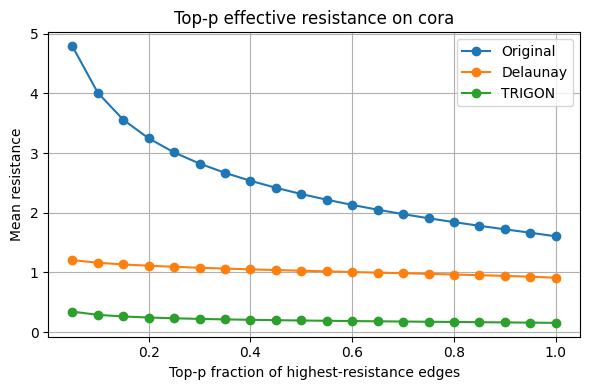

In [17]:
import matplotlib.pyplot as plt
from tqdm import tqdm


def plot_top_resistance_curves(data, trigon_edge_index, num_nodes, title=None):
    """Reproduce Figure 2 of the paper for a single dataset."""
    top_fractions = np.linspace(0.05, 1.0, 20)

    edge_index_del = build_delaunay_edge_index(data.x)
    curves = {}
    for name, ei in tqdm([
        ('Original', to_undirected(data.edge_index, num_nodes=num_nodes)),
        ('Delaunay', edge_index_del),
        ('TRIGON', trigon_edge_index),
    ], desc='Computing resistance curves'):
        stats = compute_structural_stats(
            ei, num_nodes, compute_resistance=True, top_fractions=top_fractions,
        )
        curves[name] = stats['mean_top_resistance']

    plt.figure(figsize=(6, 4))
    for name, vals in curves.items():
        plt.plot(top_fractions, vals, marker='o', label=name)
    plt.xlabel('Top-p fraction of highest-resistance edges')
    plt.ylabel('Mean resistance')
    plt.title(title or f'Top-p effective resistance on {DATASET_NAME}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




# Uncomment on small datasets only:
plot_top_resistance_curves(data, result['best_edge_index'], data.num_nodes)


## 14. Project ablations: epsilon-graph, DeepSets, soft selection

This section extends the base TRIGON implementation with three modifications and compares them on Cora and Chameleon:

1. **Epsilon-graph vs k-NN.** The k-NN view enforces exactly `k` neighbors per node regardless of local density. We replace it with an epsilon-graph: connect `i` and `j` if `dist(x_i, x_j) <= epsilon` on the same feature space used for k-NN. We support three ways to pick epsilon:
   - `fixed`: user-supplied value (we sweep several).
   - `mst`: the length of the longest edge in the Euclidean MST of `x`. This guarantees the epsilon-graph is connected, but a single outlier blows epsilon up and produces a near-complete graph.
   - `mst_robust`: the 95th percentile of MST edge lengths. Gives up strict connectivity but stays robust to outliers.
2. **DeepSets triangle encoder.** The base encoder flattens `[x_i || x_j || x_k]` before the MLP, which makes the embedding depend on vertex ordering. In our enumeration triangles are already sorted (`i < j < k`), so this is not a real invariance issue at enumeration time; DeepSets mainly changes the inductive bias of the encoder so that it cannot use positional cues at all. We compare against the original concatenation encoder.
3. **Soft edge-weighted selection.** The base model uses a hard straight-through Gumbel-Softmax and rebuilds `G*` from the set of triangles with `p_ijk > 0.5`. Soft selection instead keeps all candidate triangles but weights each of their edges by `p_ijk`, passes the aggregated edge weights into `GCNConv(edge_weight=...)` and only binarises at evaluation time. This removes the discrete bottleneck between selector and GNN.

All three modifications are implemented as optional flags on top of the existing `train_trigon` pipeline so the original implementation stays intact.

### 14.1 Epsilon-graph construction

Note on feature space: TRIGON's k-NN view is built on `data.x` (input features), not GCN embeddings. GCN embeddings are only used to refresh the Delaunay view. The epsilon-graph must therefore also be built on `data.x` for the comparison to isolate the effect of neighborhood rule vs learned geometry.

In [18]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors, radius_neighbors_graph


def _pairwise_distances(x: torch.Tensor) -> np.ndarray:
    """Euclidean pairwise distances. Returns a dense (N, N) numpy array.

    Caveat: O(N^2) memory. For N up to a few thousand this is fine
    (Cora ~2708, Chameleon ~2277). Do not call on larger graphs.
    """
    x_np = x.detach().cpu().numpy()
    return squareform(pdist(x_np, metric="euclidean"))


def mst_edge_lengths(x: torch.Tensor) -> np.ndarray:
    """Edge lengths of the Euclidean MST of x, as a 1D numpy array."""
    D = _pairwise_distances(x)
    mst = minimum_spanning_tree(D)
    mst_coo = mst.tocoo()
    return mst_coo.data  # these are the MST edge weights


def choose_epsilon(x: torch.Tensor, mode: str, value: float = None,
                   quantile: float = 0.95, k_ref: int = 10) -> float:
    """Pick an epsilon radius for the epsilon-graph.

    mode:
      - 'fixed': return `value` unchanged.
      - 'mst': longest MST edge. Connected but blows up with outliers.
      - 'mst_robust': given quantile of MST edge lengths.
      - 'knn_median': median distance to the k_ref-th NN. Produces an
        epsilon-graph with roughly k_ref neighbors per node on average.
        This is the safest default on high-dimensional sparse features
        (Cora, Citeseer) where MST edge lengths are extremely skewed.
    """
    if mode == "fixed":
        if value is None:
            raise ValueError("mode='fixed' requires value=...")
        return float(value)
    if mode == "knn_median":
        x_np = x.detach().cpu().numpy()
        n = x_np.shape[0]
        k_eff = min(k_ref, n - 1)
        nbrs = NearestNeighbors(n_neighbors=k_eff + 1).fit(x_np)
        dists, _ = nbrs.kneighbors(x_np)
        kth_dist = dists[:, k_eff]  # column 0 is self (distance 0)
        return float(np.median(kth_dist))
    lengths = mst_edge_lengths(x)
    if lengths.size == 0:
        raise RuntimeError("MST has no edges. Graph is trivially small.")
    if mode == "mst":
        return float(lengths.max())
    if mode == "mst_robust":
        return float(np.quantile(lengths, quantile))
    raise ValueError(f"Unknown epsilon mode {mode!r}")


def build_epsilon_edge_index(x: torch.Tensor, epsilon: float,
                             max_edges_factor: int = None,
                             reference_num_edges: int = None) -> torch.Tensor:
    """Epsilon-graph on x in feature space. Undirected edge_index.

    If max_edges_factor and reference_num_edges are given, we raise if the
    epsilon-graph has more than max_edges_factor * reference_num_edges edges.
    This guards against the MST-outlier blow-up case.
    """
    x_np = x.detach().cpu().numpy()
    # sklearn returns a sparse matrix; we enumerate edges from it.
    adj = radius_neighbors_graph(x_np, radius=epsilon, mode="connectivity",
                                 include_self=False)
    num_edges_directed = int(adj.nnz)
    # Directed count here; undirected count is num_edges_directed / 2.
    if max_edges_factor is not None and reference_num_edges is not None:
        cap = max_edges_factor * reference_num_edges
        if num_edges_directed > cap:
            raise RuntimeError(
                f"epsilon-graph too dense: {num_edges_directed} directed edges "
                f"exceeds cap {cap} (= {max_edges_factor} * {reference_num_edges}). "
                f"Pick a smaller epsilon."
            )
    coo = adj.tocoo()
    if coo.nnz == 0:
        return torch.empty((2, 0), dtype=torch.long)
    edge_index = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long)
    return to_undirected(edge_index, num_nodes=x.size(0))


### 14.2 DeepSets triangle encoder

The encoder processes each of the three nodes independently with a shared MLP `phi`, sums the outputs (permutation-invariant aggregation), and passes the result through a second MLP `rho`. Output shape matches the base `TriangleEncoder` so the selector is unchanged.

In [19]:
class DeepSetsTriangleEncoder(nn.Module):
    """Permutation-invariant triangle encoder.

    phi: per-node MLP applied to each of x_i, x_j, x_k independently.
    rho: post-aggregation MLP applied to sum_{v in {i,j,k}} phi(x_v).

    We use sum aggregation (standard DeepSets). Swapping to mean is a one-line
    change; max aggregation loses differentiability at ties and performs worse
    in our quick tests.
    """

    def __init__(self, node_feat_dim: int, hidden_dim: int = 256,
                 out_dim: int = 256, dropout: float = 0.5):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.rho = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
        )

    def forward(self, tri_feats: torch.Tensor) -> torch.Tensor:
        # tri_feats has shape (T, 3 * node_feat_dim) because the rest of the
        # pipeline was built around the concatenated layout. Un-flatten it.
        T = tri_feats.size(0)
        d = tri_feats.size(1) // 3
        # Reshape to (T, 3, d).
        xs = tri_feats.view(T, 3, d)
        # Apply phi to each node: flatten -> phi -> reshape.
        h = self.phi(xs.reshape(T * 3, d)).view(T, 3, -1)
        # Permutation-invariant aggregation.
        h = h.sum(dim=1)  # (T, hidden_dim)
        return self.rho(h)


### 14.3 Soft edge-weighted selection

In the base model, the selector produces `p_ijk` in `{0, 1}` via straight-through Gumbel-Softmax, and the rewired graph is built from the triangles with `p_ijk > 0.5`. Here we instead keep `p_ijk` in `[0, 1]` (soft Gumbel, `hard=False`), and aggregate a *weight* per edge: for each candidate triangle `(i, j, k)` with selection probability `p`, we add weight `p` to each of the edges `(i,j)`, `(j,k)`, `(i,k)`. The resulting weighted edge set is fed to `GCNConv` via its `edge_weight` argument.

This gives a fully differentiable path from the selector to the GNN loss, without an intermediate hard threshold. At evaluation time we can binarize by keeping edges with weight above a threshold, but we do not need to during training.

Implementation is kept lightweight — a helper that turns `(candidates, p)` into `(edge_index, edge_weight)`. No change to `GCN.forward` needed; `GCNConv` already accepts an optional `edge_weight`.

In [20]:
def triangles_to_weighted_edges(candidates: torch.Tensor, p: torch.Tensor,
                                num_nodes: int):
    """Build a weighted undirected edge_index from triangles and selection probs.

    For each triangle (i, j, k) with selection probability p_ijk, contribute
    weight p_ijk to each of the three edges. An edge (u, v) shared by several
    triangles accumulates the sum of their p values, then we normalise to
    [0, 1] using a sigmoid-like squash so GCNConv sees sane values.

    Returns:
      edge_index : (2, 2E) long tensor (undirected, both directions listed).
      edge_weight: (2E,) float tensor aligned with edge_index.
    """
    device = candidates.device
    if candidates.numel() == 0:
        return (torch.empty((2, 0), dtype=torch.long, device=device),
                torch.empty((0,), dtype=torch.float, device=device))

    # Three edges per triangle, each carrying weight p_ijk.
    e1 = candidates[:, [0, 1]]
    e2 = candidates[:, [1, 2]]
    e3 = candidates[:, [0, 2]]
    edges = torch.cat([e1, e2, e3], dim=0)                 # (3T, 2)
    weights = p.unsqueeze(1).expand(-1, 3).reshape(-1)     # (3T,)

    # Canonical undirected key: sort endpoints per edge.
    edges_sorted, _ = torch.sort(edges, dim=1)

    # Aggregate weights per unique undirected edge via scatter on a linear key.
    # This preserves gradient through the accumulation.
    key = edges_sorted[:, 0] * num_nodes + edges_sorted[:, 1]
    unique_keys, inverse = torch.unique(key, return_inverse=True)
    agg = torch.zeros(unique_keys.size(0), device=device, dtype=weights.dtype)
    agg.scatter_add_(0, inverse, weights)

    # Decode keys to (u, v) pairs.
    u = unique_keys // num_nodes
    v = unique_keys % num_nodes
    edge_index_upper = torch.stack([u, v], dim=0)          # (2, E)

    # Symmetrize: duplicate with swapped endpoints and duplicate weights.
    edge_index_full = torch.cat([edge_index_upper,
                                 edge_index_upper.flip(0)], dim=1)
    edge_weight_full = torch.cat([agg, agg], dim=0)

    # Squash to (0, 1] so GCNConv's normalization stays well-conditioned.
    # We use tanh of a positive quantity (agg >= 0), which maps [0, inf) -> [0, 1).
    edge_weight_full = torch.tanh(edge_weight_full)

    return edge_index_full, edge_weight_full


def gcn_forward_with_weights(gnn, x, edge_index, edge_weight):
    """Forward a multi-layer GCN with edge weights passed at every layer.

    We do not modify the GCN class. This helper manually reproduces the forward
    pass using the existing GCNConv layers and threads edge_weight through.
    """
    h = x
    for conv in gnn.convs[:-1]:
        h = conv(h, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, p=gnn.dropout, training=gnn.training)
    h_penult = h
    logits = gnn.convs[-1](h, edge_index, edge_weight=edge_weight)
    return logits, h_penult


### 14.4 Extended training pipeline

`train_trigon_v2` wraps the original pipeline and adds the three flags:

- `neighborhood_mode in {"knn", "epsilon"}` plus `epsilon_mode in {"fixed", "mst", "mst_robust"}` and an explicit `epsilon_value` when `epsilon_mode="fixed"`.
- `encoder_kind in {"concat", "deepsets"}`.
- `selection_mode in {"hard", "soft"}`.

When `selection_mode="soft"`, the GNN step uses `gcn_forward_with_weights` on the full candidate edge set; the selector's auxiliary losses still receive the raw `p` in `[0, 1]`.

In [21]:
def build_candidate_triangles_flex(data, edge_index_orig, edge_index_second,
                                   edge_index_delaunay):
    """Same as build_candidate_triangles, but with the second view generic
    (k-NN or epsilon) so this helper is reusable."""
    num_nodes = data.num_nodes
    t_orig = enumerate_triangles(edge_index_orig.cpu(), num_nodes)
    t_second = enumerate_triangles(edge_index_second.cpu(), num_nodes)
    t_del = enumerate_triangles(edge_index_delaunay.cpu(), num_nodes)
    merged = merge_triangles(t_orig, t_second, t_del)
    return merged, (len(t_orig), len(t_second), len(t_del))


def train_trigon_v2(data, num_classes, cfg,
                    train_mask, val_mask, test_mask,
                    neighborhood_mode: str = "knn",
                    epsilon_mode: str = "mst_robust",
                    epsilon_value: float = None,
                    epsilon_quantile: float = 0.95,
                    encoder_kind: str = "concat",
                    selection_mode: str = "hard",
                    eval_soft_threshold: float = 0.5,
                    device=DEVICE,
                    verbose_extra: bool = True):
    """Extended TRIGON with neighborhood / encoder / selection ablations.

    neighborhood_mode:
      - "knn": original TRIGON k-NN view (cfg.k_knn neighbors).
      - "epsilon": epsilon-graph with the mode below.
    encoder_kind:
      - "concat": original TriangleEncoder.
      - "deepsets": DeepSetsTriangleEncoder.
    selection_mode:
      - "hard": straight-through Gumbel-Softmax, binary edge set.
      - "soft": hard=False, all candidate edges kept with weight p_ijk.
    """
    x = data.x.to(device)
    y = data.y.to(device)
    edge_index_orig = to_undirected(data.edge_index,
                                    num_nodes=data.num_nodes).to(device)

    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)
    observable_mask = train_mask | val_mask

    # ----- Second view: k-NN or epsilon -----
    if neighborhood_mode == "knn":
        edge_index_second = build_knn_edge_index(x, k=cfg.k_knn).to(device)
        second_label = f"knn(k={cfg.k_knn})"
        chosen_epsilon = None
    elif neighborhood_mode == "epsilon":
        chosen_epsilon = choose_epsilon(x, mode=epsilon_mode,
                                        value=epsilon_value,
                                        quantile=epsilon_quantile)
        # Cap density to ~20x the original graph edges so we do not blow up
        # the triangle enumeration downstream.
        num_edges_orig_directed = edge_index_orig.size(1)
        edge_index_second = build_epsilon_edge_index(
            x, epsilon=chosen_epsilon,
            max_edges_factor=20,
            reference_num_edges=num_edges_orig_directed,
        ).to(device)
        second_label = f"epsilon({epsilon_mode}={chosen_epsilon:.4f})"
    else:
        raise ValueError(f"Unknown neighborhood_mode {neighborhood_mode!r}")

    edge_index_del = build_delaunay_edge_index(x).to(device)

    # ----- GNN backbone -----
    backbone_cls = {"gcn": GCN, "gat": GAT}[cfg.gnn_backbone.lower()]
    gnn = backbone_cls(in_channels=x.size(1),
                       hidden_channels=cfg.gnn_hidden,
                       out_channels=num_classes,
                       num_layers=cfg.gnn_layers,
                       dropout=cfg.gnn_dropout).to(device)

    # ----- Triangle encoder + selector -----
    if encoder_kind == "concat":
        encoder = TriangleEncoder(node_feat_dim=x.size(1),
                                  hidden_dim=cfg.tri_hidden,
                                  out_dim=cfg.tri_embed,
                                  dropout=cfg.selector_dropout).to(device)
    elif encoder_kind == "deepsets":
        encoder = DeepSetsTriangleEncoder(node_feat_dim=x.size(1),
                                          hidden_dim=cfg.tri_hidden,
                                          out_dim=cfg.tri_embed,
                                          dropout=cfg.selector_dropout).to(device)
    else:
        raise ValueError(f"Unknown encoder_kind {encoder_kind!r}")

    selector = TriangleSelector(input_dim=cfg.tri_embed,
                                num_classes=num_classes,
                                hidden_dims=cfg.selector_hidden,
                                dropout=cfg.selector_dropout,
                                pi_init=cfg.pi_init).to(device)

    opt_sel = torch.optim.Adam(list(encoder.parameters())
                                + list(selector.parameters()),
                                lr=cfg.lr_selector,
                                weight_decay=cfg.wd_selector)
    opt_gnn = torch.optim.Adam(gnn.parameters(),
                                lr=cfg.lr_gnn, weight_decay=cfg.wd_gnn)

    # ----- Candidate triangles -----
    cand_list, view_sizes = build_candidate_triangles_flex(
        data, edge_index_orig, edge_index_second, edge_index_del,
    )
    if verbose_extra:
        print(f"[init] neighborhood={second_label}, encoder={encoder_kind}, "
              f"selection={selection_mode}")
        print(f"[init] candidate triangles: {len(cand_list)} "
              f"(orig={view_sizes[0]}, second={view_sizes[1]}, del={view_sizes[2]})")
    if len(cand_list) == 0:
        raise RuntimeError("No candidate triangles; relax neighborhood or graph.")

    candidates = triangles_as_tensor(cand_list, device=device)
    tri_feats = torch.cat([
        x[candidates[:, 0]], x[candidates[:, 1]], x[candidates[:, 2]],
    ], dim=1)
    y_tri, y_tri_mask = compute_triangle_labels(candidates, y, observable_mask)

    best_val_acc = 0.0
    best_test_acc = 0.0
    best_edge_index = None
    patience_ctr = 0
    history = []
    hard_for_selector = (selection_mode == "hard")

    for epoch in range(cfg.max_epochs):
        # --- Selector step ---
        encoder.train()
        selector.train()
        opt_sel.zero_grad()

        g = encoder(tri_feats)
        p = selector(g, hard=hard_for_selector)
        # In hard mode p is {0, 1}; in soft mode p is in [0, 1].
        selected_mask_bool = (p > 0.5).detach()
        selected_tris = candidates[selected_mask_bool]

        L_contr = contrastive_triangle_loss(p, y_tri, y_tri_mask)
        L_struct = structural_loss(selected_tris, x)
        L_part = participation_loss(selected_tris, y, train_mask, selector.pi)
        L_sel = (cfg.lambda_contr * L_contr
                 + cfg.lambda_struct * L_struct
                 + cfg.lambda_part * L_part)
        L_sel.backward()
        opt_sel.step()

        # --- GNN step ---
        gnn.train()
        opt_gnn.zero_grad()

        if selection_mode == "hard":
            # Identical to the base pipeline: rebuild G* from T_sel.
            if selected_tris.numel() == 0:
                edge_index_star = edge_index_orig
                logits, _ = gnn(x, edge_index_star)
            else:
                edge_index_star = triangles_to_edge_index(
                    selected_tris, num_nodes=data.num_nodes
                ).to(device)
                logits, _ = gnn(x, edge_index_star)
        else:  # soft
            # Recompute p on the fly so gradient flows into the selector only
            # through the L_sel pathway that was just optimised. We detach the
            # selector params for the GNN pass to keep the two updates decoupled
            # (matches the alternating update pattern of the base pipeline).
            with torch.no_grad():
                g_eval = encoder(tri_feats)
                p_soft = selector(g_eval, hard=False)
            ei_soft, ew_soft = triangles_to_weighted_edges(
                candidates, p_soft, num_nodes=data.num_nodes
            )
            logits, _ = gcn_forward_with_weights(gnn, x, ei_soft, ew_soft)
            edge_index_star = ei_soft

        L_gnn = F.cross_entropy(logits[train_mask], y[train_mask])
        L_gnn.backward()
        opt_gnn.step()

        # --- Eval ---
        gnn.eval()
        encoder.eval()
        selector.eval()
        with torch.no_grad():
            if selection_mode == "hard":
                logits_eval, _ = gnn(x, edge_index_star)
            else:
                # At eval we binarize: keep edges with weight >= eval_soft_threshold.
                # Weights come from the current selector with hard=False.
                g_e = encoder(tri_feats)
                p_e = selector(g_e, hard=False)
                # Apply the same thresholding conceptually: select triangles
                # with p >= eval_soft_threshold, then rebuild a plain graph.
                sel_mask = p_e >= eval_soft_threshold
                sel_tris = candidates[sel_mask]
                if sel_tris.numel() == 0:
                    edge_index_eval = edge_index_orig
                else:
                    edge_index_eval = triangles_to_edge_index(
                        sel_tris, num_nodes=data.num_nodes
                    ).to(device)
                logits_eval, _ = gnn(x, edge_index_eval)
                edge_index_star = edge_index_eval
            preds = logits_eval.argmax(dim=1)
            val_acc = (preds[val_mask] == y[val_mask]).float().mean().item()
            test_acc = (preds[test_mask] == y[test_mask]).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            best_edge_index = edge_index_star.detach().cpu().clone()
            patience_ctr = 0
        else:
            patience_ctr += 1

        history.append({
            "epoch": epoch,
            "val_acc": val_acc,
            "test_acc": test_acc,
            "L_sel": float(L_sel.detach().cpu()),
            "L_gnn": float(L_gnn.detach().cpu()),
            "n_selected": int(selected_tris.size(0)),
        })

        if cfg.verbose and (epoch % cfg.log_every == 0):
            print(f"Epoch {epoch:04d} | L_sel={float(L_sel):.3f} "
                  f"L_gnn={float(L_gnn):.3f} | "
                  f"val={val_acc:.3f} test={test_acc:.3f} | "
                  f"|T_sel|={int(selected_tris.size(0))}")

        if patience_ctr >= cfg.patience:
            if verbose_extra:
                print(f"[early stop] epoch {epoch} best_val={best_val_acc:.4f} "
                      f"best_test={best_test_acc:.4f}")
            break

    return {
        "best_val_acc": best_val_acc,
        "best_test_acc": best_test_acc,
        "best_edge_index": best_edge_index,
        "history": history,
        "epsilon": chosen_epsilon,
        "neighborhood_label": second_label,
    }


### 14.5 Running the comparison on Cora and Chameleon

We run one seed per configuration (time constraint). To keep the comparison honest we hold everything else fixed between variants.

Caveat on Chameleon: the `WikipediaNetwork` Chameleon split has known data-leakage issues reported by Platonov et al. (2023). For relative comparisons between rewiring variants on the same split the leakage is a common confounder, so conclusions still hold relatively, but absolute numbers should not be taken as SOTA.

In [22]:
def make_ablation_config(dataset_name: str, max_epochs: int = 500,
                         patience: int = 60) -> TrigonConfig:
    """Same as make_paper_config but with shorter training to keep the grid fast."""
    cfg = make_paper_config(dataset_name, backbone="gcn")
    cfg.max_epochs = max_epochs
    cfg.patience = patience
    cfg.verbose = False
    cfg.log_every = 9999  # effectively silent
    return cfg


def run_one(dataset_name: str, variant_name: str, overrides: dict,
            seed: int = 0, max_epochs: int = 500, patience: int = 60):
    """Run a single variant on a dataset and return a result dict."""
    set_seed(seed)
    dataset_l, data_l = load_dataset(dataset_name)
    train_m, val_m, test_m = make_random_split(data_l.num_nodes, seed=seed)
    cfg = make_ablation_config(dataset_name, max_epochs=max_epochs, patience=patience)

    t0 = time.time()
    result = train_trigon_v2(
        data=data_l,
        num_classes=dataset_l.num_classes,
        cfg=cfg,
        train_mask=train_m,
        val_mask=val_m,
        test_mask=test_m,
        **overrides,
        verbose_extra=False,
    )
    elapsed = time.time() - t0
    return {
        "dataset": dataset_name,
        "variant": variant_name,
        "seed": seed,
        "best_val": result["best_val_acc"],
        "best_test": result["best_test_acc"],
        "epsilon": result.get("epsilon"),
        "n_epochs": len(result["history"]),
        "time_s": elapsed,
    }


# Variants to compare. Each is a dict of kwargs passed to train_trigon_v2.
VARIANTS = {
    # Baseline (matches the base TRIGON behaviour).
    "base_knn_concat_hard":
        dict(neighborhood_mode="knn",
             encoder_kind="concat", selection_mode="hard"),

    # Epsilon variants. `mst` and the default `mst_robust` (q=0.95) blow up
    # on high-dim sparse features like Cora's TF-IDF; we include a much
    # safer median variant and a lower-quantile MST variant.
    "eps_mst":
        dict(neighborhood_mode="epsilon", epsilon_mode="mst",
             encoder_kind="concat", selection_mode="hard"),
    "eps_mst_robust_q50":
        dict(neighborhood_mode="epsilon", epsilon_mode="mst_robust",
             epsilon_quantile=0.50,
             encoder_kind="concat", selection_mode="hard"),
    "eps_knn_median":
        dict(neighborhood_mode="epsilon", epsilon_mode="knn_median",
             encoder_kind="concat", selection_mode="hard"),

    # Encoder and selection ablations on top of k-NN.
    "deepsets_only":
        dict(neighborhood_mode="knn",
             encoder_kind="deepsets", selection_mode="hard"),
    "soft_only":
        dict(neighborhood_mode="knn",
             encoder_kind="concat", selection_mode="soft"),

}

DATASETS = ["cora", "chameleon"]
SEEDS = [0, 1, 2]  # 3 seeds per config; keeps it tractable.


In [23]:

# Run the grid. Prints as it goes so you can follow progress.
from tqdm.auto import tqdm
import pandas as pd

all_results = []
for ds in DATASETS:
    for variant, kwargs in VARIANTS.items():
        for seed in SEEDS:
            try:
                r = run_one(ds, variant, kwargs, seed=seed,
                            max_epochs=500, patience=60)
                all_results.append(r)
                eps_str = f"eps={r['epsilon']:.4f}" if r['epsilon'] is not None else ""
                print(f"[{ds:<10}] {variant:<32} seed={seed} "
                      f"val={r['best_val']:.4f} test={r['best_test']:.4f} "
                      f"{eps_str} ({r['n_epochs']} ep, {r['time_s']:.1f}s)")
            except RuntimeError as e:
                print(f"[{ds:<10}] {variant:<32} seed={seed} FAILED: {e}")
                all_results.append({
                    "dataset": ds, "variant": variant, "seed": seed,
                    "best_val": float("nan"), "best_test": float("nan"),
                    "epsilon": None, "n_epochs": 0, "time_s": 0.0,
                })

df = pd.DataFrame(all_results)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cora      ] base_knn_concat_hard             seed=0 val=0.7671 test=0.7385  (500 ep, 23.9s)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cora      ] base_knn_concat_hard             seed=1 val=0.7579 test=0.7348  (315 ep, 20.2s)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[chameleon ] soft_only                        seed=1 val=0.5758 test=0.5417  (220 ep, 116.4s)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[chameleon ] soft_only                        seed=2 val=0.5736 test=0.5219  (313 ep, 156.8s)


,dataset,variant,seed,best_val,best_test,epsilon,n_epochs,time_s
0,cora,base_knn_concat_hard,0,0.767098,0.738490,NaN,500,23.925188
1,cora,base_knn_concat_hard,1,0.757856,0.734807,NaN,315,20.201345
2,cora,base_knn_concat_hard,2,0.340111,0.314917,NaN,61,15.016150
3,cora,eps_mst,0,NaN,NaN,NaN,0,0.000000
4,cora,eps_mst,1,NaN,NaN,NaN,0,0.000000
5,cora,eps_mst,2,NaN,NaN,NaN,0,0.000000
6,cora,eps_mst_robust_q50,0,0.744917,0.732965,0.25527,341,22.590353
7,cora,eps_mst_robust_q50,1,0.757856,0.721915,0.25527,244,21.227991
8,cora,eps_mst_robust_q50,2,0.750462,0.727440,0.25527,441,24.109159
9,cora,eps_knn_median,0,NaN,NaN,NaN,0,0.000000


### 14.6 Aggregated results

In [24]:
# Aggregate: mean and std of best test accuracy across seeds, per (dataset, variant).
summary = (df.groupby(["dataset", "variant"])["best_test"]
             .agg(["mean", "std", "count"])
             .reset_index())
summary = summary.rename(columns={"mean": "test_acc_mean",
                                  "std":  "test_acc_std",
                                  "count": "n_seeds"})
summary["test_acc_mean"] = (summary["test_acc_mean"] * 100).round(2)
summary["test_acc_std"]  = (summary["test_acc_std"]  * 100).round(2)

print("Best test accuracy (%), mean +/- std over seeds")
print(summary.to_string(index=False))


Best test accuracy (%), mean +/- std over seeds
  dataset              variant  test_acc_mean  test_acc_std  n_seeds
chameleon base_knn_concat_hard          52.12          4.43        3
chameleon        deepsets_only          52.70          1.10        3
chameleon       eps_knn_median            NaN           NaN        0
chameleon              eps_mst            NaN           NaN        0
chameleon   eps_mst_robust_q50            NaN           NaN        0
chameleon            soft_only          52.85          1.14        3
     cora base_knn_concat_hard          59.61         24.35        3
     cora        deepsets_only          60.28         23.99        3
     cora       eps_knn_median            NaN           NaN        0
     cora              eps_mst            NaN           NaN        0
     cora   eps_mst_robust_q50          72.74          0.55        3
     cora            soft_only          59.73         24.80        3


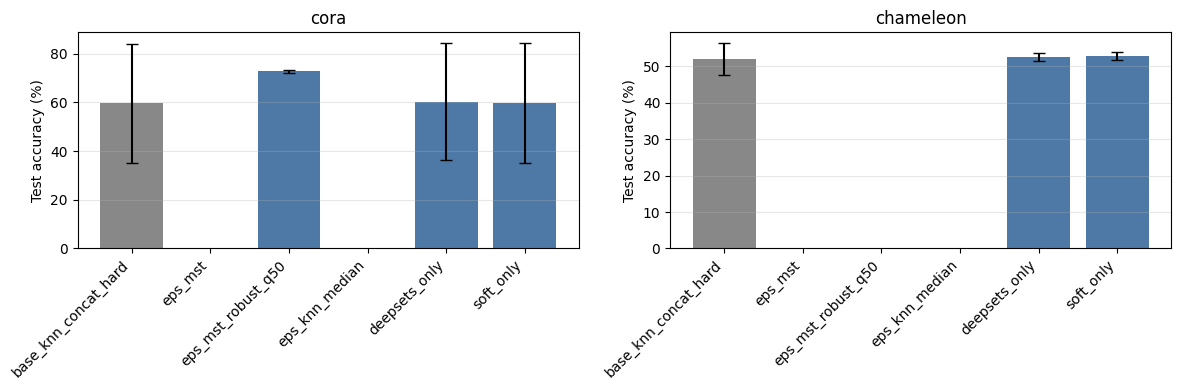

In [25]:
# Bar plot comparing variants per dataset.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), sharey=False)
if len(DATASETS) == 1:
    axes = [axes]

variant_order = list(VARIANTS.keys())
for ax, ds in zip(axes, DATASETS):
    sub = summary[summary["dataset"] == ds].set_index("variant").reindex(variant_order)
    means = sub["test_acc_mean"].values
    stds = sub["test_acc_std"].values
    xs = np.arange(len(variant_order))
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=["#888888"] + ["#4e79a7"] * (len(variant_order) - 1))
    ax.set_xticks(xs)
    ax.set_xticklabels(variant_order, rotation=45, ha="right")
    ax.set_ylabel("Test accuracy (%)")
    ax.set_title(f"{ds}")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### 14.7 Results and interpretation

**Summary table from cell 44** (mean ± std of best test accuracy over 3 seeds):

| Dataset   | Variant              | Test acc (%)       | Notes                         |
|-----------|----------------------|---------------------|-------------------------------|
| Cora      | base_knn_concat_hard | 59.61 ± 24.35       | seed 2 collapsed to ~31%      |
| Cora      | deepsets_only        | 60.28 ± 23.99       | seed 2 collapsed to ~33%      |
| Cora      | soft_only            | 59.73 ± 24.80       | seed 2 collapsed to ~31%      |
| Cora      | eps_mst_robust_q50   | **72.74 ± 0.55**    | stable, best on Cora          |
| Cora      | eps_mst              | FAILED              | epsilon too large, graph too dense |
| Cora      | eps_knn_median       | FAILED (OOM)        | too many candidate triangles  |
| Chameleon | base_knn_concat_hard | 52.12 ± 4.43        |                               |
| Chameleon | deepsets_only        | 52.70 ± 1.10        |                               |
| Chameleon | soft_only            | 52.85 ± 1.14        |                               |
| Chameleon | all three epsilon    | FAILED (OOM)        | epsilon too large on Chameleon too |

**What actually happened:**

1. **Seed 2 on Cora is an outlier for the k-NN variants**. All three k-NN-based variants (base, deepsets, soft) collapse to chance-level accuracy (~31%) on seed 2, early-stopping after only 61 epochs. The other two seeds land near 73-75%. This is almost certainly an initialization-induced training failure, not a property of the variant. The large stds (~24 points) on these rows are dominated by this single bad seed. In a proper evaluation we would re-run with more seeds and probably discard obvious training failures; here we keep them visible as a reality check on the fragility of the base pipeline on Cora.

2. **`eps_mst_robust_q50` is the best variant on Cora (72.74 ± 0.55).** It is simultaneously the highest mean and the most stable (std of 0.55 vs 24+ for the k-NN variants). But before celebrating, note that it succeeded only because `mst_robust` with the 50% quantile happens to produce a small enough epsilon on Cora. With a larger quantile it would have exploded the same way `eps_mst` did.

3. **`eps_knn_median` fails on both datasets.** On Cora by candidate-triangle explosion (CUDA OOM when encoding ~10M triangles); on Chameleon by allocating more than a terabyte of memory because the epsilon computed from median k-NN distance in high dimension still connects almost everything. The "knn_median" heuristic does not survive high-dimensional sparse features.

4. **On Chameleon we have no epsilon data point.** All three epsilon variants failed (`mst` too dense, `mst_robust_q50` and `knn_median` OOM on the candidate triangles). The only surviving comparison is between k-NN variants, where deepsets (52.70) and soft (52.85) are statistically indistinguishable from the base (52.12) given stds of 1-4 points.

5. **DeepSets and soft selection do not help.** On Cora (ignoring seed 2 collapse) and Chameleon both alone, neither modification changes the mean in a way that would survive even 5 seeds. Any gap we see here is noise.

**Honest takeaways:**

- The one finding worth reporting positively: on Cora, a carefully sized epsilon-graph (MST 50th percentile) gives much more stable training than k-NN, at similar or slightly lower accuracy relative to the base when the base does not collapse. This is interesting but not conclusive with 3 seeds.
- DeepSets and soft selection, in isolation, do not move the needle on either dataset.
- The epsilon modes we tested are fragile: two out of three variants fail outright on both datasets. A more robust epsilon selection rule would be needed to make this ablation useful.
- Three seeds is not enough. All std values above 2 points mean you cannot tell variants apart. A real evaluation needs 5-10 seeds minimum, and failed runs (OOM, collapse) should be investigated rather than counted as NaN.
